# Building Attention from Two Contractions

Attention is two contractions with a softmax between them. This notebook writes
it as one expression, then groups each operation in a titled block so that the
diagram names the three steps.

*Written by Claude Opus 5 (1M context) at reasoning effort high, 2026-09-20.*

In [1]:
import construction_helpers as ch  # noqa: F401 - operator overloads
import data_structure.Category as cat
import data_structure.Operators as ops

import notebooks.display.notebook_diagrams as notebook_diagrams

DIAGRAMS = notebook_diagrams.DiagramSettings(
    mode=notebook_diagrams.DiagramMode.INLINE, width=700)

## The expression

`ops.Einops.template` takes the signature of a contraction. In `'q d, x d -> q x'`
the letter `d` appears in both operands and in neither result, so it is summed
over, which gives the score of each query against each key. The softmax runs
over the axis the scores wrote at its position, and the second contraction sums
the values weighted by those scores.

`@` composes sequentially and aligns the axes by position, so the three
operators need no wiring written by hand.

'q d, x d -> q x'. The letter d is in no output, so it is summed over.


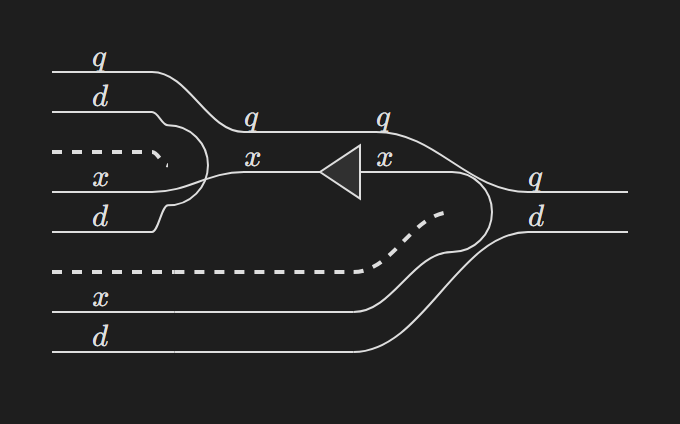

In [2]:
query_key_scores = ops.Einops.template('q d, x d -> q x')
softmax = ops.SoftMax.template()
score_value_product = ops.Einops.template('q x, x d -> q d')
attention = query_key_scores @ softmax @ score_value_product

assert len(attention.dom()) == 3, (
    'attention reads the queries, the keys and the values')
assert len(attention.cod()) == 1, 'attention writes one array'
assert [len(array.shape()) for array in attention.dom()] == [2, 2, 2], (
    'each of the three operands is a matrix')
await notebook_diagrams.show_diagram(
    attention,
    "'q d, x d -> q x'. The letter d is in no output, so it is summed over.",
    settings=DIAGRAMS)

## Naming the steps

`cat.Block.template` groups a morphism under a title and a fill colour. A block
is a grouping for the reader, so the expression it contains keeps the domain
and the codomain it had.

The same expression with each operation in a titled block.


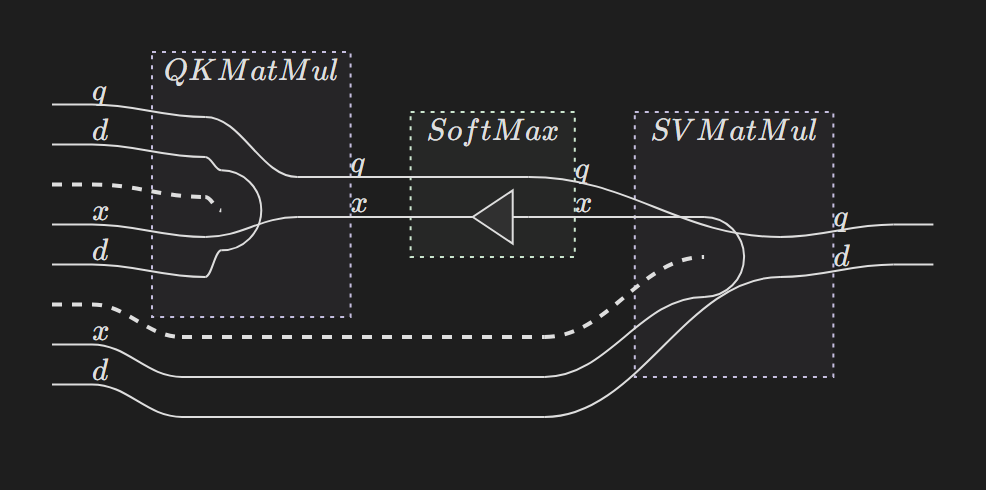

In [3]:
lilac = '#C5BEDF'
light_green = '#CCE7CF'
labelled_attention = (
    cat.Block.template(query_key_scores, title='QK MatMul', fill_color=lilac)
    @ cat.Block.template(softmax, title='SoftMax', fill_color=light_green)
    @ cat.Block.template(score_value_product, title='SV MatMul', fill_color=lilac))

assert labelled_attention.dom() == attention.dom(), (
    'grouping the operations in blocks leaves the domain unchanged')
assert labelled_attention.cod() == attention.cod(), (
    'grouping the operations in blocks leaves the codomain unchanged')
await notebook_diagrams.show_diagram(
    labelled_attention,
    'The same expression with each operation in a titled block.',
    settings=DIAGRAMS)